In [1]:
from pathlib import Path
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim

import numpy as np
from tqdm import tqdm

In [2]:
%reload_ext tensorboard
%tensorboard --logdir ../runs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/home/chris/miniconda3/envs/ramenv/bin/tensorboard", line 6, in <module>
    from tensorboard.main import run_main
  File "/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/home/chris/miniconda3/envs/ramenv/lib/python3.11/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

In [12]:
rows, cols = 64, 64

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DATA_DIR = Path("../data/dataset2-master/dataset2-master/images")
TENSORBOARD_LOG_DIR = Path("../runs/lenet_original")
TENSORBOARD_LOG_DIR.mkdir(parents=True, exist_ok=True)

TENSORBOARD_BN_LOG_DIR = Path("../runs/lenet_bn")
TENSORBOARD_BN_LOG_DIR.mkdir(parents=True, exist_ok=True)

train_dir = DATA_DIR / "TRAIN"
test_dir = DATA_DIR / "TEST"

In [4]:
transform = transforms.Compose([
    transforms.Resize((rows, cols)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train = datasets.ImageFolder(train_dir, transform=transform)
test = datasets.ImageFolder(test_dir, transform=transform)

In [5]:
BATCH_SIZE = 32
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
class LeNet(nn.Module):
    def __init__(self, num_classes: int = 10):
        super(LeNet, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            nn.Flatten(1, -1),
            
            nn.Linear(16 * 13 * 13, 120),
            nn.Tanh(),
            
            nn.Linear(120, 84),
            nn.Tanh(),
            
            nn.Linear(84, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)
        

In [7]:
def train(model, device, train_loader, optimizer, criterion, epoch, writer=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Training epoch {epoch}")
    for batch_idx, (data, target) in progress_bar:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        batch_loss = loss.item()
        running_loss += batch_loss * data.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        batch_acc = correct / total
        global_step = (epoch - 1) * len(train_loader) + batch_idx
        
        progress_bar.set_postfix(loss=batch_loss, acc=batch_acc)
        if writer is not None:
            writer.add_scalar("Loss/train_batch", batch_loss, global_step)
            writer.add_scalar("Accuracy/train_batch", batch_acc, global_step)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    if writer is not None:
        writer.add_scalar("Loss/train_epoch", epoch_loss, epoch)
        writer.add_scalar("Accuracy/train_epoch", epoch_acc, epoch)
    return epoch_loss, epoch_acc


def evaluate(model, device, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            
            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model_original = LeNet(num_classes=4)
model_original.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_original.parameters(), lr=0.1, momentum=0.0, weight_decay=0.0)
writer = SummaryWriter(log_dir=str(TENSORBOARD_LOG_DIR))

cuda


In [9]:
EPOCHS = 10

try:
    sample_images, _ = next(iter(train_loader))
    writer.add_graph(model_original, sample_images.to(device))
except Exception as exc:
    print(f"No se pudo registrar el grafo en TensorBoard: {exc}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model_original, device, train_loader, optimizer, criterion, epoch, writer)
    test_loss, test_acc = evaluate(model_original, device, test_loader, criterion)
    
    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    tqdm.write(
        f"Epoch {epoch}/{EPOCHS} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
    )

writer.close()
torch.save(model_original.state_dict(), "../models/lenet_original.pth")

Training epoch 1: 100%|██████████| 312/312 [00:30<00:00, 10.11it/s, acc=0.299, loss=1.37]


Epoch 1/10 - train_loss: 1.3736 - train_acc: 0.2988 - test_loss: 1.4355 - test_acc: 0.2497


Training epoch 2: 100%|██████████| 312/312 [00:28<00:00, 11.06it/s, acc=0.37, loss=1.26] 


Epoch 2/10 - train_loss: 1.3074 - train_acc: 0.3702 - test_loss: 1.2020 - test_acc: 0.4672


Training epoch 3: 100%|██████████| 312/312 [00:26<00:00, 11.93it/s, acc=0.421, loss=1.38] 


...

Epoch 8/10 - train_loss: 0.7681 - train_acc: 0.6794 - test_loss: 0.9577 - test_acc: 0.5858


Training epoch 9: 100%|██████████| 312/312 [00:27<00:00, 11.54it/s, acc=0.757, loss=0.518]


Epoch 9/10 - train_loss: 0.5902 - train_acc: 0.7572 - test_loss: 1.0918 - test_acc: 0.5424


Training epoch 10: 100%|██████████| 312/312 [00:24<00:00, 12.64it/s, acc=0.814, loss=0.656]


Epoch 10/10 - train_loss: 0.4549 - train_acc: 0.8143 - test_loss: 1.5819 - test_acc: 0.4990


In [10]:
class LeNetBN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super(LeNetBN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),
            nn.BatchNorm2d(6),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(6, 16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            nn.Flatten(1, -1),
            
            nn.Linear(16 * 13 * 13, 120),
            nn.Tanh(),
            
            nn.Linear(120, 84),
            nn.Tanh(),
            
            nn.Linear(84, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)
        

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model_bn = LeNetBN(num_classes=4)
model_bn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_bn.parameters(), lr=0.1, momentum=0.0, weight_decay=0.0)
writer = SummaryWriter(log_dir=str(TENSORBOARD_BN_LOG_DIR))

cuda


In [14]:
EPOCHS = 10

try:
    sample_images, _ = next(iter(train_loader))
    writer.add_graph(model_bn, sample_images.to(device))
except Exception as exc:
    print(f"No se pudo registrar el grafo en TensorBoard: {exc}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train(model_bn, device, train_loader, optimizer, criterion, epoch, writer)
    test_loss, test_acc = evaluate(model_bn, device, test_loader, criterion)
    
    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", test_acc, epoch)
    tqdm.write(
        f"Epoch {epoch}/{EPOCHS} - "
        f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
        f"test_loss: {test_loss:.4f} - test_acc: {test_acc:.4f}"
    )

writer.close()
torch.save(model_bn.state_dict(), "../models/lenet_bn.pth")

Training epoch 1: 100%|██████████| 312/312 [00:25<00:00, 12.01it/s, acc=0.42, loss=1.15]  


Epoch 1/10 - train_loss: 1.2492 - train_acc: 0.4202 - test_loss: 2.8399 - test_acc: 0.2493


Training epoch 2: 100%|██████████| 312/312 [00:26<00:00, 11.99it/s, acc=0.584, loss=0.485]


Epoch 2/10 - train_loss: 0.9475 - train_acc: 0.5835 - test_loss: 3.3361 - test_acc: 0.2537


Training epoch 3: 100%|██████████| 312/312 [00:26<00:00, 11.56it/s, acc=0.712, loss=0.489]


...

Epoch 8/10 - train_loss: 0.1903 - train_acc: 0.9286 - test_loss: 3.4170 - test_acc: 0.4556


Training epoch 9: 100%|██████████| 312/312 [00:30<00:00, 10.17it/s, acc=0.966, loss=0.136] 


Epoch 9/10 - train_loss: 0.1024 - train_acc: 0.9658 - test_loss: 7.1258 - test_acc: 0.2469


Training epoch 10: 100%|██████████| 312/312 [00:27<00:00, 11.20it/s, acc=0.964, loss=1.08]  


Epoch 10/10 - train_loss: 0.1006 - train_acc: 0.9642 - test_loss: 4.8816 - test_acc: 0.2795


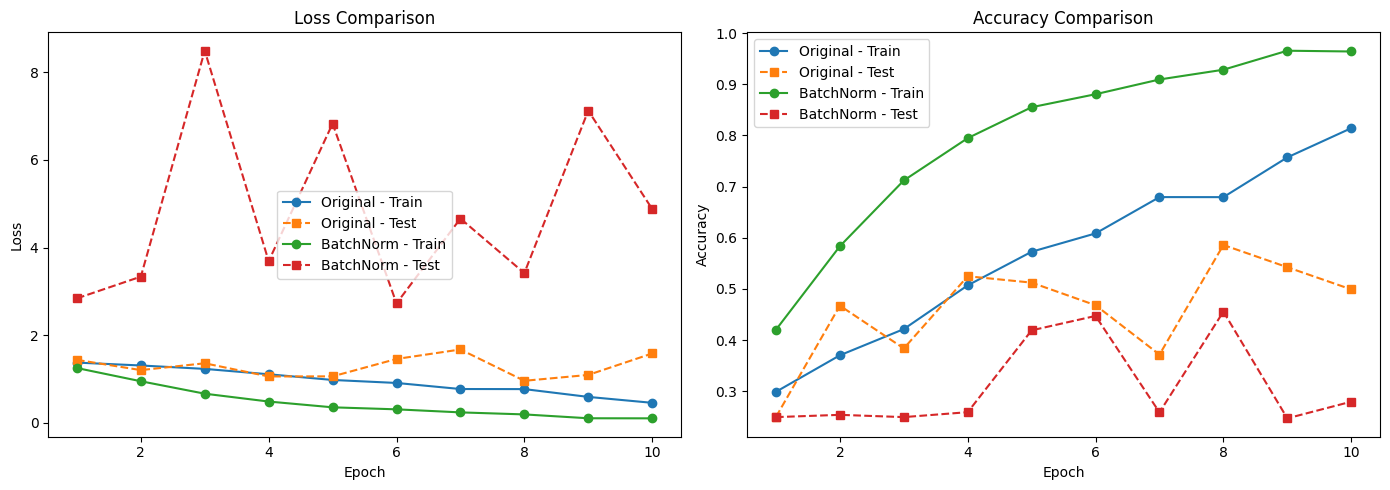

In [16]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

import matplotlib.pyplot as plt

def load_scalars(log_dir, tag):
    ea = EventAccumulator(str(log_dir))
    ea.Reload()
    if tag not in ea.Tags().get("scalars", []):
        return [], []
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return steps, values

metrics = [
    ("Loss/train_epoch", "Train Loss"),
    ("Loss/test", "Test Loss"),
    ("Accuracy/train_epoch", "Train Accuracy"),
    ("Accuracy/test", "Test Accuracy"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for log_dir, label in [
    (TENSORBOARD_LOG_DIR, "Original"),
    (TENSORBOARD_BN_LOG_DIR, "BatchNorm"),
]:
    for tag, _ in metrics:
        steps, values = load_scalars(log_dir, tag)
        if not steps:
            continue
        ax = axes[0] if "Loss" in tag else axes[1]
        split = 'Train' if 'train' in tag.lower() else 'Test'
        linestyle = '-' if split == 'Train' else '--'
        marker = 'o' if split == 'Train' else 's'
        ax.plot(steps, values, linestyle=linestyle, marker=marker, label=f"{label} - {split}")

axes[0].set_title("Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()